In [116]:
import DataMaker
import DataHolder
import buildmodel

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import glob
import json

import cartopy.crs as ccrs

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [90]:
ssplist = ["126","245","370","585"]
# ssplist = ["245","370","585"]

In [91]:
# ssplist = ["245"]#,"370","585"]

# set user parameters

# historical_era = [1960,2000]
experiment_era = [1950,2100]
baselineera = [1900,1950]
# tpercentile = 95
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

inputlength = 10
outputavgtime = 10

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

In [92]:
imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
}

ntrain = 25
nval = 13
test = np.arange(38,50)


#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


When does the likelihood of experiencing a record maximum summer in the next n-year period becomes more likely than not?

In [93]:
len(AllData.alloutput)

endhist = 2014

emergenceyear = np.empty((4,len(AllData.output_lat),len(AllData.output_lon)))+np.nan

for ilatsel,latsel in enumerate(AllData.output_lat):
    print(latsel)
    for ilonsel,lonsel in enumerate(AllData.output_lon):

        if latsel<0:
            season = 2
        else:
            season = 8

        latindsel = np.argmin(np.abs((AllData.output_lat-latsel)))
        lonindsel = np.argmin(np.abs((AllData.output_lon-lonsel)))

        gmthistorical = [1960,1990]
        gmthistoricalinds = [gmthistorical[0]-AllData.timerange[0],gmthistorical[1]-AllData.timerange[0]]
        historicalinds = [experiment_era[0]-AllData.timerange[0],endhist-AllData.timerange[0]+outputavgtime]

        baselineindices = [baselineera[0]-AllData.timerange[0],baselineera[1]-AllData.timerange[0]]

        recordtemps = np.zeros((len(AllData.ssplist),AllData.alloutput[0].shape[0],AllData.alloutput[0].shape[1]))

        if season ==8:
            timevec = np.arange(experiment_era[0]+inputlength,2100-outputavgtime+2)
        elif season==2:
            timevec = np.arange(experiment_era[0]+inputlength,2100-outputavgtime+1)

        for issp,ssp in enumerate(AllData.ssplist):

            histsel = AllData.alloutput[issp]
            histsel = histsel[:,:,latindsel,lonindsel]

            baseline = np.max(histsel[:,baselineindices[0]:baselineindices[1]],axis=1)
            
            for iens in range(histsel.shape[0]):

                recordtemps[issp,iens,:] = DataHolder.find_records(histsel[iens,:],baseline[iens])

            output_recordtemps_hist = recordtemps[issp,:,historicalinds[0]:]
            # stack it
            stackedoutput = DataHolder.stackmatalongdim1(output_recordtemps_hist,outputavgtime)

                # cut it
            cutoutput = stackedoutput[:,inputlength:]
            # control for season
            if season==2:
                cutoutput = cutoutput[:,1:]
            # number of extremes in a future period

            nevents = np.sum(cutoutput,axis=2)
            outputrecordsummer = 1*(nevents>0) # any number >0 is a yes

            meanoutputrecord = np.mean(outputrecordsummer,axis=0)

            # yearind = np.argmin(np.abs(outputrecordsummer-0.5))
            yearind = np.where(meanoutputrecord > 0.5)[0]
            if len(yearind) > 0: 
                emergenceyear[issp,ilatsel,ilonsel] = timevec[yearind[0]]






-90
-80
-70
-60
-50
-40
-30
-20
-10
0
10
20
30
40
50
60
70
80


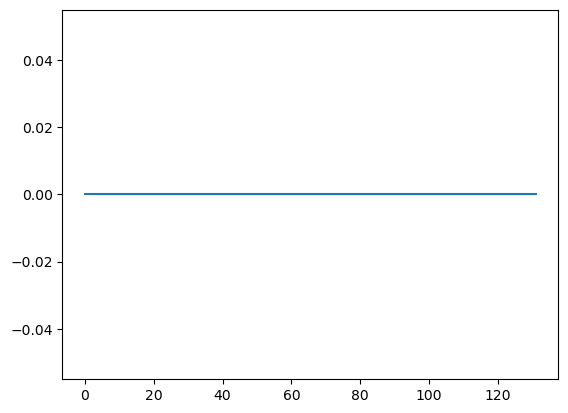

In [94]:
plt.plot(meanoutputrecord)

Text(0.5, 0, 'year')

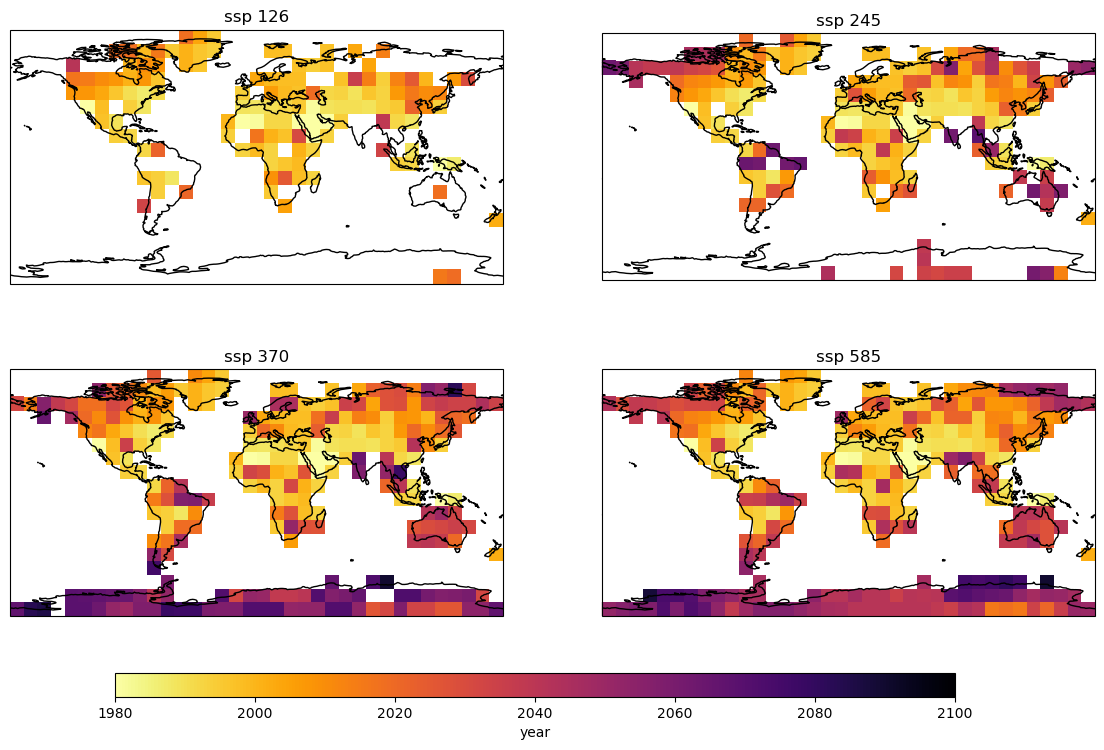

In [95]:
plt.figure(figsize=(14,8))

for iplot in range(4):
    a1=plt.subplot(2,2,iplot+1,projection=ccrs.PlateCarree())
    c1=a1.pcolormesh(AllData.output_lon+5,AllData.output_lat+5,emergenceyear[iplot],vmin=1980,vmax=2100,cmap='inferno_r')
    a1.coastlines()

    plt.title('ssp ' + ssplist[iplot])

cax = plt.axes((0.2,0.03,0.6,0.03))
cbar=plt.colorbar(c1,cax=cax,orientation='horizontal')

cbar.ax.set_xlabel('year')

### Some useful functions

In [96]:
def GMTexprob(GMTvec,outputprobs):
    bins = np.arange(-1,5.05,0.05)

    GMTvec = np.squeeze(GMTvec)
    outputprobs = np.squeeze(outputprobs)
    binprobs = []
    for ibin,binval in enumerate(bins[:-1]):
        if len(outputprobs.shape)==2:
            exs = outputprobs[(GMTvec>=binval) & (GMTvec<bins[ibin+1]),1]
        elif len(outputprobs.shape)==1:
            exs = outputprobs[(GMTvec>=binval) & (GMTvec<bins[ibin+1])]
        if len(exs) == 0:
            prob = np.nan
        else:
            prob = exs.mean()
        binprobs.append(prob)
    
    return np.asarray(binprobs),bins


In [97]:
def bininputdata(GMTvec,inputdata):
    bins = np.arange(-1,5.01,0.01)

    GMTvec = np.squeeze(GMTvec)
    inputbinned = torch.ones(inputdata.shape)

    for ibin,binval in enumerate(bins[:-1]):

        inputbinned[(GMTvec>=binval) & (GMTvec<bins[ibin+1])] = torch.mean(inputdata[(GMTvec>=binval) & (GMTvec<bins[ibin+1])],axis=0)[None]

    return inputbinned,bins

In [98]:
def binandshuffleinputdata(GMTvec,inputdata):
    bins = np.arange(-1,5.5,0.5)

    GMTvec = np.squeeze(GMTvec)
    inputbinnedshuffled = torch.ones(inputdata.shape)

    for ibin,binval in enumerate(bins[:-1]):

        inputgrab = inputdata[(GMTvec>=binval) & (GMTvec<bins[ibin+1])]
        nperm = inputgrab.shape[0]
        permedindex = np.random.choice(nperm,nperm,replace=False)
        inputshuffle = inputgrab[permedindex]

        inputbinnedshuffled[(GMTvec>=binval) & (GMTvec<bins[ibin+1])] = inputshuffle

    return inputbinnedshuffled,bins

In [99]:
def get_best_models(metricfilewc,n_best=3, metric="val_loss",):
    results = []
    for file in glob.glob(metricfilewc):
        with open(file, 'r') as f:
            results.append(json.load(f))
    
    reverse = metric == "accuracy"
    best_models = sorted(results, key=lambda x: x[metric], reverse=reverse)[:n_best]
    return best_models

In [100]:
latsel = -30
lonsel = 140

In [101]:
metricfilewc = metricsout = "metrics/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_lon*.json"

results = []
for file in glob.glob(metricfilewc):
    with open(file, 'r') as f:
        results.append(json.load(f))


allaccs = np.asarray([results[i]['val_accuracy'] for i in range(len(glob.glob(metricfilewc)))])
allnulls = np.asarray([results[i]['val_class_imbalance'] for i in range(len(glob.glob(metricfilewc)))])
    
bestseedinds = np.argsort(allaccs-allnulls)[-3:]

loadseeds = [results[i]['seed'] for i in bestseedinds]

In [ ]:
# plt.subplot(1,1,1)
allpred = []
allpredshuff = []

nshuff = 10

trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)

trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

alltrain, _, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

inputtest, inputtestGMT, outputtest = DataHolder.tensortime_onehot(alltest,nclasses=2)

for seed in loadseeds:

    torch.manual_seed(seed) 
    np.random.seed(seed)

    inputtestshuffle = []
    for ishuff in range(nshuff):
        inputshuff,_ = binandshuffleinputdata(inputtestGMT,inputtest)
        inputtestshuffle.append(inputshuff)
    
    outputtestclass = np.argmax(outputtest.numpy(),axis=1)

    cnn = buildmodel.CNNclassifier(inputtest, inputtestGMT, outputtest.shape[1])
    fileout = "models/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_lon"+str(lonsel)+"_seed"+str(seed)+".pt"
    cnn.load_state_dict(torch.load(fileout, weights_only=True, map_location=torch.device('cpu')))
    # cnn.to('mps')
    cnn.eval()

    predshuff = []
    with torch.no_grad():
        
        predtest = cnn(inputtest, inputtestGMT)

        for ishuff in range(nshuff):
            predshuffloop = cnn(inputtestshuffle[ishuff],inputtestGMT).numpy()
            predshuff.append(predshuffloop)
    
    predshuff = np.asarray(predshuff)
    avgpredshuff = np.mean(predshuff,axis=0)

    allpred.append(predtest.numpy()[:,1])
    allpredshuff.append(avgpredshuff[:,1])

    predtestclass = torch.argmax(predtest, dim=1).numpy()

    acctest = np.mean(predtestclass == outputtestclass)

    print("Seed ", str(seed), "test imbalance: ", str(1-np.mean(outputtestclass)))
    print("Seed ", str(seed), " test accuracy: ", str(acctest))

    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")



baseline for gmt is 60 90
experiment era in the historical is 50 124
baseline for temp records is 0 50
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/DataHolder.py:1272: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


Seed  62469869 test imbalance:  0.5912576687116564
Seed  62469869  test accuracy:  0.6193762781186094
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Seed  71856281 test imbalance:  0.5912576687116564
Seed  71856281  test accuracy:  0.6252556237218814
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Seed  47621498 test imbalance:  0.5912576687116564
Seed  47621498  test accuracy:  0.6273006134969326
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [120]:
model = LogisticRegression()

inputtrainGMT = alltrain[1]
outputtrain = alltrain[2]
# Fit the model
model.fit(inputtrainGMT, outputtrain)

# Make predictions
y_pred = model.predict(inputtestGMT.numpy())
y_pred_proba = model.predict_proba(inputtestGMT.numpy())  # Get probabilities

# Evaluate
accuracy = accuracy_score(outputtest[:,1], y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(outputtest[:,1], y_pred))

# Access coefficients
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Accuracy: 0.6107
              precision    recall  f1-score   support

         0.0       0.62      0.89      0.73      2313
         1.0       0.56      0.21      0.31      1599

    accuracy                           0.61      3912
   macro avg       0.59      0.55      0.52      3912
weighted avg       0.60      0.61      0.56      3912

Coefficients: [[0.75881297]]
Intercept: [-1.35601156]


/opt/homebrew/Cellar/micromamba/2.3.1/envs/ml-env/lib/python3.9/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


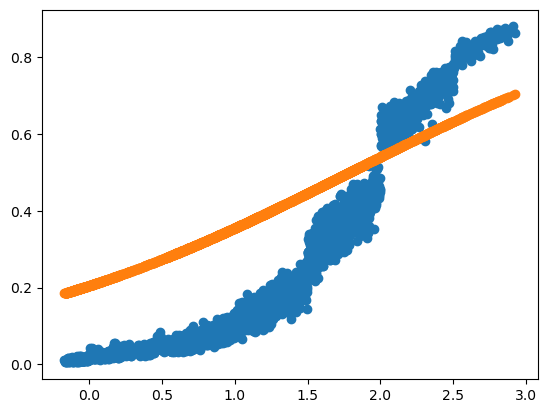

In [121]:
allpredshuff = np.asarray(allpredshuff)

plt.scatter(inputtestGMT.numpy(),np.mean(allpredshuff,axis=0))
plt.scatter(inputtestGMT.numpy(),y_pred_proba[:,1])

In [104]:
allpred = np.asarray(allpred)

In [105]:
allpredmean = np.mean(allpred,axis=0)
allpredmeanclass = np.round(allpredmean)

allpredacc = np.mean(allpredmeanclass==outputtestclass)
allpredacc

0.6273006134969326

In [106]:
allshuffmean = np.mean(allpredshuff,axis=0)
allshuffclass = np.round(allshuffmean)

allshuffacc = np.mean(allshuffclass==outputtestclass)
allshuffacc

0.6117075664621677

In [107]:
outputprobstest,outputprobsbin = GMTexprob(inputtestGMT,outputtest)

outputshuffprobs,_ = GMTexprob(inputtestGMT,allshuffclass)
outputmeanprobs,_ = GMTexprob(inputtestGMT,allpredmeanclass)

In [108]:
inputbinned,inputbins = binandshuffleinputdata(inputtestGMT,inputtest)

testpredshufflesst = cnn(inputbinned,inputtestGMT).detach().numpy()


In [109]:
def binandpredict(GMTvec,inputdata,cnn):
    bins = np.arange(-1,4.3,0.3)

    meanpred = torch.empty(len(bins))

    for ibin,binval in enumerate(bins[:-1]):

        indsgrab = (GMTvec.squeeze()>=binval) & (GMTvec.squeeze()<bins[ibin+1])
        inputgrab = inputdata[indsgrab]

        if inputgrab.shape[0]==0:
            meanpred[ibin]=np.nan
        else:

            with torch.no_grad():
                shuffpredgmt = cnn(inputgrab,GMTvec[indsgrab])
            
            meanpred[ibin] = torch.mean(shuffpredgmt[:,1])

    return meanpred,bins

In [110]:
shuffpred,bins = binandpredict(inputtestGMT,inputtest,cnn)

In [111]:
numsamps = [0,55,79,79,79,79,]
numearlier = np.cumsum(numsamps)

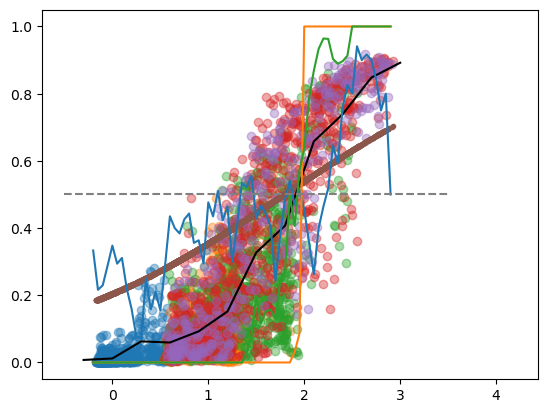

In [122]:
for iplot in range(5):

    plt.scatter(inputtestGMT.numpy()[12*numearlier[iplot]:12*numearlier[iplot+1]],predtest[12*numearlier[iplot]:12*numearlier[iplot+1],1],alpha=0.4)

# plt.scatter(inputtestGMT.numpy(),testpredshufflesst[:,1],marker='.')
plt.plot(bins+0.1,shuffpred,color='black')
plt.plot(outputprobsbin[:-1],outputprobstest)

plt.scatter(inputtestGMT.numpy(),y_pred_proba[:,1],marker='.')

plt.plot(outputprobsbin[:-1],outputshuffprobs)

plt.plot(outputprobsbin[:-1],outputmeanprobs)


plt.hlines(0.5,-0.5,3.5,color='gray',linestyle='dashed')

In [113]:
allsummer = []

for i in range(5):
    truesummer = AllData.truesummer[i][25:38].flatten()
    allsummer.extend(truesummer)

ValueError: x and y must be the same size

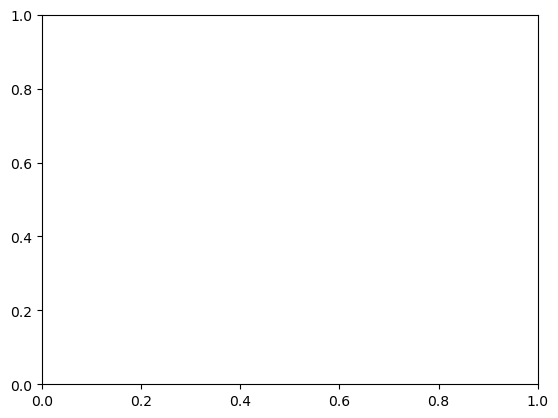

In [114]:
plt.scatter(allsummer,allpred[-1],c=inputtestGMT.numpy())
plt.colorbar()

In [ ]:
AllData.truesummer[2].shape

(50, 79)

In [ ]:
allpred[0][:,1].shape

(4823,)

In [ ]:
confusion_mat = np.empty((2,2))
confusion_mat_gmt = np.empty((2,2))

for i in range(2):
    for j in range(2):

        confusion_mat[i,j] = np.mean(1*((predvalclass==i) & (outputvalclass==j)))
        # confusion_mat_gmt[i,j] = np.mean(1*((nullval==i) & (outputvalclass==j)))

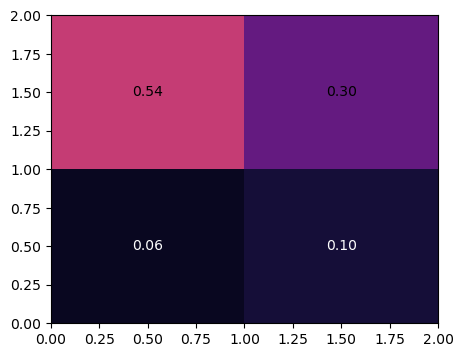

In [ ]:
plt.figure(figsize=(5,4))

im1 = plt.pcolormesh(np.flipud(confusion_mat),vmin=0,vmax=1,cmap='magma')
nrows, ncols = confusion_mat.shape
for i in range(nrows):
    for j in range(ncols):
        val = confusion_mat[i, j]
        if abs(val - round(val)) < 1e-8:
            s = str(int(round(val)))
        else:
            s = "{:.2f}".format(val)
        x = j + 0.5
        y = nrows - i - 0.5
        text_color = 'white' if val < (confusion_mat.max() / 2.0) else 'black'
        plt.text(x, y, s, ha='center', va='center', color=text_color)


# plt.subplot(1,2,2)
# plt.pcolormesh(np.flipud(confusion_mat_gmt),vmin=0,vmax=1,cmap='magma')
# nrows2, ncols2 = confusion_mat_gmt.shape
# for i in range(nrows2):
#     for j in range(ncols2):
#         val = confusion_mat_gmt[i, j]
#         if abs(val - round(val)) < 1e-8:
#             s = str(int(round(val)))
#         else:
#             s = "{:.2f}".format(val)
#         x = j + 0.5
#         y = nrows2 - i - 0.5
#         text_color = 'white' if val < (confusion_mat_gmt.max() / 2.0) else 'black'
#         plt.text(x, y, s, ha='center', va='center', color=text_color)

In [ ]:
f1score = 2*confusion_mat[1,1]/(2*confusion_mat[1,1] + confusion_mat[1,0] + confusion_mat[0,1])
print(f1score)

# f1score_gmt = 2*confusion_mat_gmt[1,1]/(2*confusion_mat_gmt[1,1] + confusion_mat_gmt[1,0] + confusion_mat_gmt[0,1])
# print(f1score_gmt)

0.36523652365236525


In [ ]:
trainvaltest

[array([34,  7, 27, 11, 25, 21,  3,  8, 22, 29,  2, 26, 15,  6, 20,  9,  5,
        19,  4, 24, 31, 28, 37, 14, 36]),
 array([32,  1, 10, 12, 16, 35, 30, 23, 17, 33,  0, 13, 18]),
 array([38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])]